In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance

In [4]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025newbig2.csv')
df_cheap = df[df['Цена'] <= 700_000]
df_mid = df[(df['Цена'] >= 500_000) & (df['Цена'] < 2_000_000)]
df_exp = df[df['Цена'] >= 2_000_000]
df_mid.head()

,Название машины,Год,Цена,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,Рестайлинг,Тип кузова,Метка,Город,Год объявления,Месяц объявления,Возраст авто
3,Nissan Tiida Latio,2009.0,660000.0,1.5,бензин,109.0,CVT,передний,168000.0,правый,1.0,1.0,седан,nissan,Лесозаводск,2024,9,15.0
4,Honda Fit Shuttle,2012.0,600000.0,1.3,бензин,88.0,CVT,передний,158059.0,правый,1.0,0.0,универсал,honda,Владивосток,2021,2,9.0
5,Renault Duster,2017.0,820000.0,1.5,дизель,109.0,МКПП,4WD,95000.0,левый,1.0,1.0,джип/suv 5 дв.,renault,Норильск,2021,5,4.0
6,Ford C-MAX,2008.0,540000.0,1.8,бензин,125.0,МКПП,передний,201000.0,левый,1.0,1.0,минивэн,ford,Омск,2023,5,15.0
10,BMW 5-Series,2013.0,1050000.0,2.0,бензин,184.0,АКПП,задний,199000.0,левый,6.0,0.0,седан,bmw,Москва,2021,5,8.0


Text(0, 0.5, 'Количество автомобилей')

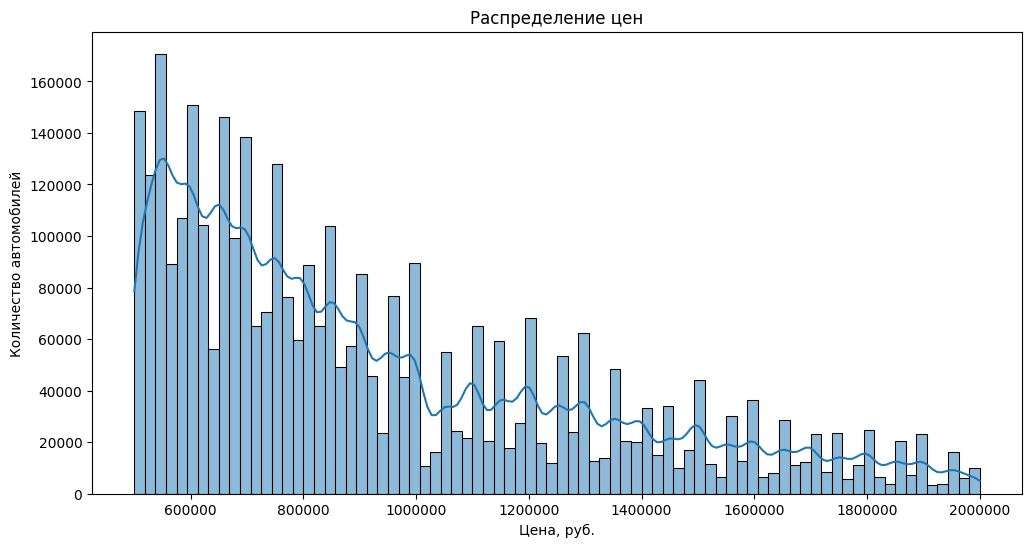

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df_mid["Цена"], bins=80, kde=True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Распределение цен')
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")

In [5]:
categorical = ['Тип двигателя', 'Коробка передач', 'Привод', 'Поколение', 'Рестайлинг',
               'Тип кузова', 'Метка', 'Город']
numerical = ['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Возраст авто']

In [6]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical), ('num', 'passthrough', numerical)], remainder='drop')

In [7]:
y = df_mid['Цена']
X = df_mid.drop('Цена', axis=1)

X_train = X[X['Год объявления'] <= 2023]
X_test = X[X['Год объявления'] >= 2024]

y_train = y[X['Год объявления'] <= 2023]
y_test = y[X['Год объявления'] >= 2024]
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=2000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
model.fit(X_train, y_train, regressor__verbose=True)
y_pred = model.predict(X_test)

In [8]:
xg_mse = mean_squared_error(y_test, y_pred)
xg_rmse = np.sqrt(xg_mse)
xg_mae = mean_absolute_error(y_test, y_pred)
xg_r2 = r2_score(y_test, y_pred)

In [9]:
pd.options.display.float_format = '{:_.2f}'.format
pd.DataFrame({
    'Метод оценки': ['Среднеквадратическая ошибка (MSE)', 'Среднеквадратическая ошибка (RMSE)', 'Средняя абсолютная ошибка (MAE)', 'Коэффицент детерминации (R^2)'],
    'Результаты': [xg_mse, xg_rmse, xg_mae, xg_r2]
})

,Метод оценки,Результаты
0,Среднеквадратическая ошибка (MSE),41_186_594_732.95
1,Среднеквадратическая ошибка (RMSE),202_944.81
2,Средняя абсолютная ошибка (MAE),152_338.78
3,Коэффицент детерминации (R^2),0.73


In [10]:
np.mean(df_mid['Цена'])

np.float64(932695.4981325057)

In [11]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.2%}")

MAPE: 14.51%


In [12]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("TOP 20 признаков:")
print(importance_df.head(20))


TOP 20 признаков:
                             feature  importance
64                   cat__Метка_lada        0.06
3719                        num__Год        0.05
10              cat__Привод_передний        0.04
67                  cat__Метка_lexus        0.04
3721                   num__Мощность        0.03
3720            num__Объем двигателя        0.03
35    cat__Тип кузова_джип/suv 5 дв.        0.03
81                 cat__Метка_toyota        0.02
6      cat__Коробка передач_редуктор        0.02
4          cat__Коробка передач_МКПП        0.02
3723               num__Возраст авто        0.01
44     cat__Тип кузова_хэтчбек 5 дв.        0.01
41             cat__Тип кузова_седан        0.01
29               cat__Рестайлинг_3.0        0.01
74                cat__Метка_peugeot        0.01
14                cat__Поколение_4.0        0.01
58                  cat__Метка_honda        0.01
53                cat__Метка_citroen        0.01
51                  cat__Метка_chery        0.01
24

In [13]:
importance_df["feature_group"] = importance_df["feature"].apply(
    lambda x: x.split("__")[1].split("_")[0]
)

grouped_importance = (
    importance_df
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nВажность исходных признаков:")
print(grouped_importance)


Важность исходных признаков:
feature_group
Город             0.35
Метка             0.27
Тип кузова        0.07
Поколение         0.06
Год               0.05
Коробка передач   0.05
Привод            0.04
Мощность          0.03
Объем двигателя   0.03
Рестайлинг        0.02
Возраст авто      0.01
Тип двигателя     0.00
Пробег            0.00
Name: importance, dtype: float32


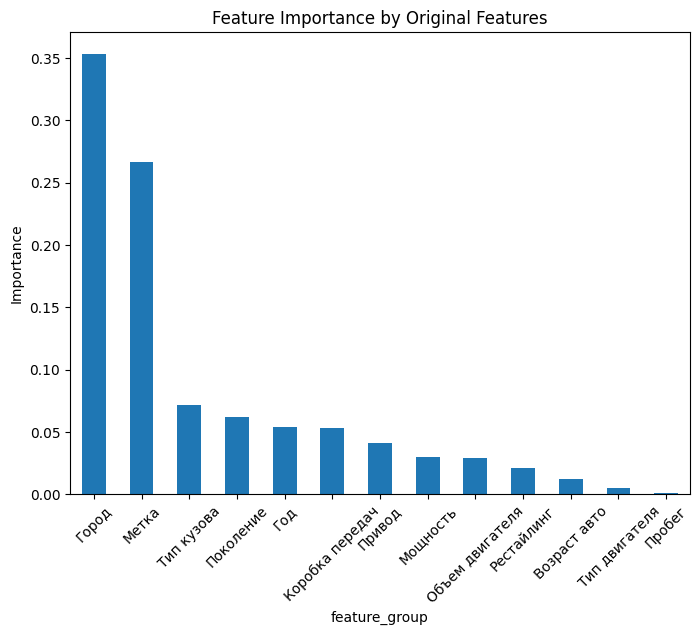

In [14]:
plt.figure(figsize=(8,6))
grouped_importance.plot(kind="bar")
plt.title("Feature Importance by Original Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()